<img src="CCDE_logotipo.png" align="right" width="200px" alt="CCDE logotipo" />

# 🏦 Credit Scoring Avanzado & MLOps Pipeline
### *Desarrollado de forma individual para el Círculo de Ciencia de Datos y Econometría*

Este notebook presenta una solución integral de **Credit Scoring con enfoque MLOps**, diseñado de forma didáctica para la enseñanza de mejores prácticas en Ciencia de Datos.

<br clear="all" />

#### 🎯 Contenidos de este Proyecto
1. **Prevenir Data Leakage**: Uso de transformadores personalizados de `scikit-learn` (`BaseEstimator`, `TransformerMixin`) para asegurar que los datos de validación no se filtren en la fase de entrenamiento.
2. **Comparativa de Modelos de Negocio**:
   * **Modelo Regulado (Baseline)**: Regresión Logística + Weight of Evidence (WoE) para máxima transparencia.
   * **Modelo Avanzado de ML**: Random Forest Classifier optimizado para máxima capacidad predictiva y detección de interacciones no lineales.
3. **Búsqueda Bayesiana con Optuna**: Optimización automatizada de hiperparámetros.
4. **Análisis Exploratorio Superior**: Visualizaciones con reflexiones de negocio (Business Insights).
5. **MLOps Ready**: Serialización del pipeline completo.


In [1]:
# Opcional: Instalar dependencias si no se encuentran en el entorno local
# !pip install -q optuna scikit-learn pandas numpy matplotlib seaborn joblib


In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
import optuna
import joblib
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score

# Configuración visual y alertas
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 12
optuna.logging.set_verbosity(optuna.logging.WARNING)


C:\Users\mauri\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Análisis Exploratorio de Datos (EDA) Profesional

Importamos el dataset `loan_approval_dataset.csv`, limpiamos los espacios del texto y nombres de columnas, y extraemos insights estratégicos.


In [ ]:
# Carga de datos desde repositorio de Github de CCDE-DataLab
data = pd.read_csv("https://raw.githubusercontent.com/CCDE-DataLab/proyectos-ciencia-de-datos/refs/heads/main/01_proy_cd_credit_scoring/loan_approval_dataset.csv")

# Limpieza de espacios en los nombres de las columnas y valores de texto
data.columns = data.columns.str.strip()
for col in data.select_dtypes(['object']).columns:
    data[col] = data[col].str.strip()

# Mapeo del Target: 0 = Approved, 1 = Rejected (Riesgo / Default)
map_status = {"Approved": 0, "Rejected": 1}
data["loan_status"] = data["loan_status"].map(map_status)

# Eliminar ID
data.drop("loan_id", axis=1, inplace=True)

# Vista previa de los datos
print(f"Dataset: {data.shape[0]} registros, {data.shape[1]} columnas")
data.head()


Dataset: 4269 registros, 12 columnas


,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,0
1,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,1
2,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,1
3,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,1
4,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,1


### 1.1 Proporción de la Clase Target
Evaluaremos la distribución del estatus del préstamo.


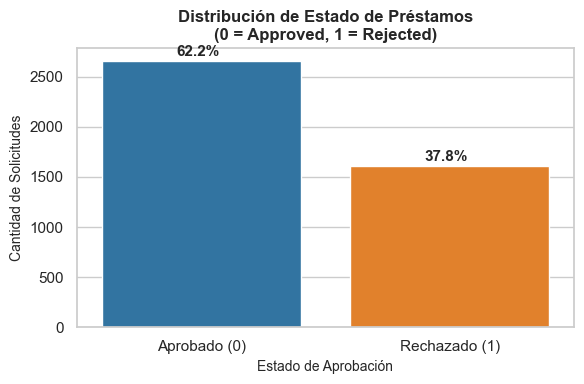

In [4]:
plt.figure(figsize=(6, 4))
ax = sns.countplot(data=data, x='loan_status', palette=['#1f77b4', '#ff7f0e'])
total = len(data)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2 - 0.1
    y = p.get_height() + 50
    ax.annotate(percentage, (x, y), fontsize=11, weight='bold')

plt.title("Distribución de Estado de Préstamos\n(0 = Approved, 1 = Rejected)", fontsize=12, weight='bold')
plt.xlabel("Estado de Aprobación", fontsize=10)
plt.ylabel("Cantidad de Solicitudes", fontsize=10)
plt.xticks([0, 1], ["Aprobado (0)", "Rechazado (1)"])
plt.tight_layout()
plt.show()


> [!NOTA]
> **Business Insight**: La clase minoritaria (préstamos rechazados) representa el 37.8% de los datos. Esta proporción permite entrenar modelos estables sin requerir técnicas de balanceo, pero utilizaremos validación cruzada estratificada para proteger la generalización.


### 1.2 Impacto del Score CIBIL en la Aprobación
El CIBIL score es el historial del buró de crédito del aplicante.


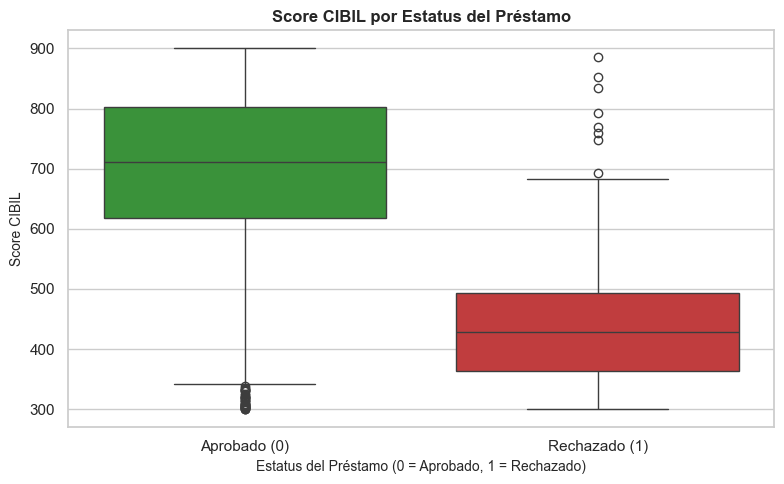

In [5]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=data, x='loan_status', y='cibil_score', palette=['#2ca02c', '#d62728'])
plt.title("Score CIBIL por Estatus del Préstamo", fontsize=12, weight='bold')
plt.xlabel("Estatus del Préstamo (0 = Aprobado, 1 = Rechazado)", fontsize=10)
plt.ylabel("Score CIBIL", fontsize=10)
plt.xticks([0, 1], ["Aprobado (0)", "Rechazado (1)"])
plt.tight_layout()
plt.show()


> [!IMPORTANTE]
> **Business Insight**: El score CIBIL separa de forma contundente las solicitudes. Un score por debajo de 550 prácticamente garantiza el rechazo, mientras que los aprobados se concentran en puntuaciones óptimas (>700). Este es el predictor más fuerte.


### 1.3 Análisis de Relación de Deuda a Ingreso (Apalancamiento)
Generamos temporalmente el ratio préstamo/ingreso para entender la distribución del endeudamiento.


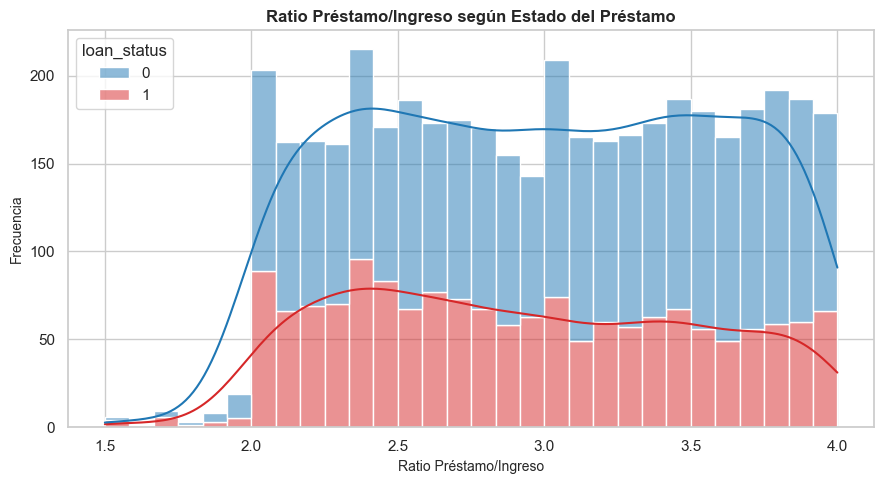

In [6]:
data_viz = data.copy()
data_viz['loan_income_ratio'] = data_viz['loan_amount'] / data_viz['income_annum']

plt.figure(figsize=(9, 5))
sns.histplot(data=data_viz, x='loan_income_ratio', hue='loan_status', kde=True, bins=30, multiple='stack', palette=['#1f77b4', '#d62728'])
plt.title("Ratio Préstamo/Ingreso según Estado del Préstamo", fontsize=12, weight='bold')
plt.xlabel("Ratio Préstamo/Ingreso", fontsize=10)
plt.ylabel("Frecuencia", fontsize=10)
plt.tight_layout()
plt.show()


> [NOTA]
> **Business Insight**: A medida que el ratio deuda/ingreso supera el valor de 3.0, el riesgo de rechazo aumenta sensiblemente. La relación entre ingresos y deuda representa el límite de capacidad de pago del solicitante.


### 1.4 Distribución Patrimonial (Activos Totales)
Calculamos la suma de todos los activos declarados por el cliente para ver si es influyente.


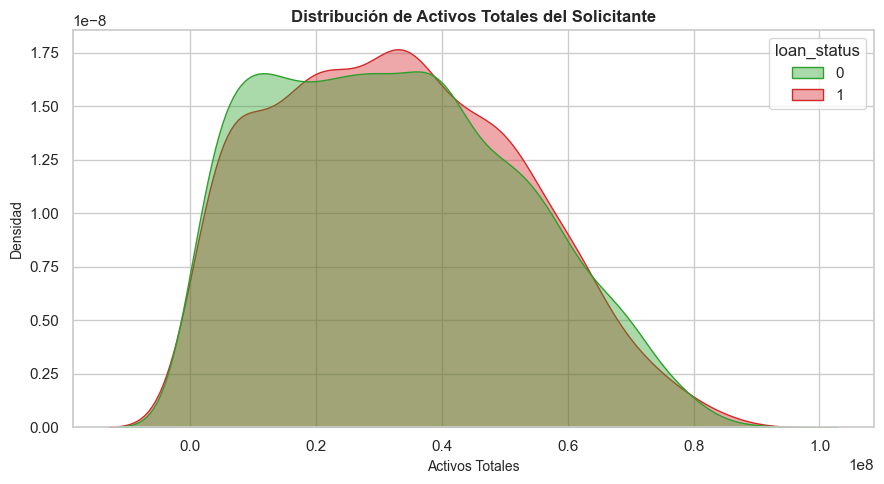

In [7]:
data_viz['total_assets'] = (data_viz['residential_assets_value'] + 
                            data_viz['commercial_assets_value'] + 
                            data_viz['luxury_assets_value'] + 
                            data_viz['bank_asset_value'])

plt.figure(figsize=(9, 5))
sns.kdeplot(data=data_viz, x='total_assets', hue='loan_status', fill=True, common_norm=False, palette=['#2ca02c', '#d62728'], alpha=0.4)
plt.title("Distribución de Activos Totales del Solicitante", fontsize=12, weight='bold')
plt.xlabel("Activos Totales", fontsize=10)
plt.ylabel("Densidad", fontsize=10)
plt.tight_layout()
plt.show()


> [!ADVERTENCIA]
> **Business Insight**: Las distribuciones de patrimonio total se superponen por completo entre las solicitudes aprobadas y rechazadas. Esto indica que los activos acumulados no tienen peso individual si el solicitante tiene un mal comportamiento de pago (CIBIL bajo) o un apalancamiento excesivo.


## 2. Ingeniería de Variables y Clases Personalizadas (Scikit-Learn)

Por medio de TransformerMixin y BaseEstimator, crearemos estimadores personalizados compatibles con `scikit-learn` para asegurar que la generación de ratios, activos y codificación WoE se realice de forma encapsulada y sin riesgo de fuga de datos. De este modo, automatizamos el flujo de los datos y evitamos posibles problemas de dataleakage


In [8]:
class RatioGenerator(BaseEstimator, TransformerMixin):
    """Genera la relación entre préstamo e ingresos."""
    def __init__(self, cols, column_name="loan_income_ratio"):
        self.cols = cols
        self.column_name = column_name
        
    def fit(self, X, y=None):
        return self
        
    def transform(self, X):
        X_copy = pd.DataFrame(X).copy()
        numerador = X_copy[self.cols[0]]
        denominador = X_copy[self.cols[1]]
        # Prevenir divisiones por cero
        ratio = np.where(denominador == 0, np.nan, numerador / denominador)
        X_copy[self.column_name] = ratio
        return X_copy[[self.column_name]]
        
    def get_feature_names_out(self, input_features=None):
        return np.array([self.column_name])


class TotalAssetsGenerator(BaseEstimator, TransformerMixin):
    """Agrega la riqueza patrimonial total sumando todos los activos declarados."""
    def __init__(self, columns, column_name="total_asset"):
        self.columns = columns
        self.column_name = column_name
        
    def fit(self, X, y=None):
        return self
        
    def transform(self, X):
        X_copy = pd.DataFrame(X).copy()
        X_copy[self.column_name] = X_copy[self.columns].sum(axis=1)
        return X_copy[[self.column_name]]
        
    def get_feature_names_out(self, input_features=None):
        return np.array([self.column_name])


class WoeGenerator(BaseEstimator, TransformerMixin):
    """
    Codificador Weight of Evidence (WoE) con selección automática por Information Value (IV).
    Aprende los cortes discretos de las numéricas en el fit y los aplica al transform.
    """
    def __init__(self, bins=5, iv_threshold=0.02):
        self.bins = bins
        self.iv_threshold = iv_threshold
        self.woe_tables_ = {}
        self.iv_values_ = {}
        self.features_to_keep_ = []
        self.bin_cuts_ = {}

    def fit(self, X, y):
        X_df = pd.DataFrame(X).copy()
        y_series = pd.Series(y).reset_index(drop=True)
        X_df = X_df.reset_index(drop=True)

        self.woe_tables_ = {}
        self.iv_values_ = {}
        self.features_to_keep_ = []
        self.bin_cuts_ = {}

        for col in X_df.columns:
            if pd.api.types.is_numeric_dtype(X_df[col]):
                _, bins_edges = pd.qcut(X_df[col], q=self.bins, duplicates="drop", retbins=True)
                bins_edges[0], bins_edges[-1] = -np.inf, np.inf
                self.bin_cuts_[col] = bins_edges
                x_binned = pd.cut(X_df[col], bins=self.bin_cuts_[col])
            else:
                x_binned = X_df[col]

            df_temp = pd.DataFrame({"feature": x_binned, "target": y_series})
            stats = df_temp.groupby("feature", observed=True)["target"].agg(["count", "sum"])
            stats.columns = ["total", "bad"]
            stats["good"] = stats["total"] - stats["bad"]

            bad_sum = stats["bad"].sum()
            good_sum = stats["good"].sum()

            stats["bad_rate"] = stats["bad"] / (bad_sum if bad_sum > 0 else 1)
            stats["good_rate"] = stats["good"] / (good_sum if good_sum > 0 else 1)

            stats["woe"] = np.log((stats["good_rate"] + 0.0001) / (stats["bad_rate"] + 0.0001))
            iv = ((stats["good_rate"] - stats["bad_rate"]) * stats["woe"]).sum()

            self.woe_tables_[col] = stats['woe'].to_dict()
            self.iv_values_[col] = iv

            if iv >= self.iv_threshold:
                self.features_to_keep_.append(col)

        return self

    def transform(self, X):
        X_df = pd.DataFrame(X).copy()
        X_transformed = pd.DataFrame(index=X_df.index)

        for col in self.features_to_keep_:
            if col in self.bin_cuts_:
                x_binned = pd.cut(X_df[col], bins=self.bin_cuts_[col])
            else:
                x_binned = X_df[col]

            X_transformed[col] = (x_binned.map(self.woe_tables_[col])
                                          .astype(float)
                                          .fillna(0.0))
        return X_transformed

    def get_feature_names_out(self, input_features=None):
        return np.array(self.features_to_keep_)


## 3. Configuración de Pipelines de Entrenamiento

Dividiremos los datos en Entrenamiento (80%) y Prueba (20%), estratificando por la variable target para prevenir el sesgo en el desbalance.


In [9]:
X = data.drop("loan_status", axis=1)
y = data["loan_status"]

# Partición estratificada
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Entrenamiento: {X_train.shape[0]} filas | Prueba: {X_test.shape[0]} filas")


Entrenamiento: 3415 filas | Prueba: 854 filas


### 3.1 Pipeline 1: Scorecard Tradicional (WoE + Regresión Logística)
Representa el estándar de la banca clásica por su alta explicabilidad y cumplimiento de normativas.


In [10]:
feature_eng_scorecard = ColumnTransformer([
    ('ratio_deuda', RatioGenerator(cols=['loan_amount', 'income_annum']), ['loan_amount', 'income_annum']),
    ('assets_totales', TotalAssetsGenerator(columns=['residential_assets_value', 'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value']),
                                            ['residential_assets_value', 'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value']),
    ('mantener', 'passthrough', ['no_of_dependents', 'education', 'self_employed', 'loan_term', 'cibil_score'])
], remainder='drop')

scorecard_pipeline = Pipeline([
    ('ingenieria', feature_eng_scorecard),
    ('woe_filter', WoeGenerator(bins=5, iv_threshold=0.02)),
    ('modelo', LogisticRegression(class_weight='balanced', random_state=42))
]).set_output(transform="pandas")


### 3.2 Pipeline 2: Machine Learning Avanzado (ML Pipeline + Random Forest)
Implementamos un clasificador **Random Forest** (bosque aleatorio) en combinación con codificación One-Hot para las variables de texto y estandarización. Las estructuras de árboles pueden procesar valores continuos directamente sin requerir WoE.


In [11]:
# ColumnTransformer para ML Pipeline
ml_preprocessor = ColumnTransformer([
    ('ratio_deuda', RatioGenerator(cols=['loan_amount', 'income_annum']), ['loan_amount', 'income_annum']),
    ('assets_totales', TotalAssetsGenerator(columns=['residential_assets_value', 'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value']),
                                            ['residential_assets_value', 'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value']),
    ('cat_encoder', OneHotEncoder(drop='first', sparse_output=False), ['education', 'self_employed']),
    ('mantener_num', 'passthrough', ['no_of_dependents', 'loan_term', 'cibil_score'])
], remainder='drop')

ml_pipeline = Pipeline([
    ('preprocessing', ml_preprocessor),
    ('scaler', StandardScaler()),
    ('modelo', RandomForestClassifier(random_state=42, class_weight='balanced'))
]).set_output(transform="pandas")


## 4. Optimización de Hiperparámetros con Optuna

Usamos Optuna para realizar optimización bayesiana maximizando el promedio de ROC-AUC bajo validación cruzada estratificada de 5 pliegues. A diferencia de Gridsearch que prueba todas las combinaciones posibles, Optuna es computacionalmente menos pesado.


In [12]:
def objective_scorecard(trial):
    # Optimizar el binning y el umbral de IV de WoE
    bins = trial.suggest_int('woe_filter__bins', 3, 12)
    iv_threshold = trial.suggest_float('woe_filter__iv_threshold', 0.005, 0.08)
    
    # Optimizar la Regresión Logística
    c_val = trial.suggest_float('modelo__C', 0.001, 10.0, log=True)
    solver = trial.suggest_categorical('modelo__solver', ['liblinear', 'lbfgs'])
    
    scorecard_pipeline.set_params(
        woe_filter__bins=bins,
        woe_filter__iv_threshold=iv_threshold,
        modelo__C=c_val,
        modelo__solver=solver
    )
    
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(scorecard_pipeline, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
    return scores.mean()

study_sc = optuna.create_study(direction='maximize')
study_sc.optimize(objective_scorecard, n_trials=15)

print("Scorecard (LogReg) - Mejor ROC-AUC CV:", study_sc.best_value)
print("Mejores Parámetros:", study_sc.best_params)


Scorecard (LogReg) - Mejor ROC-AUC CV: 0.9929977200182398
Mejores Parámetros: {'woe_filter__bins': 12, 'woe_filter__iv_threshold': 0.006707651544696162, 'modelo__C': 0.01856969013403474, 'modelo__solver': 'lbfgs'}


In [13]:
def objective_ml(trial):
    # Hiperparámetros de Random Forest
    n_estimators = trial.suggest_int('modelo__n_estimators', 50, 250)
    max_depth = trial.suggest_int('modelo__max_depth', 3, 12)
    min_samples_split = trial.suggest_int('modelo__min_samples_split', 2, 8)
    min_samples_leaf = trial.suggest_int('modelo__min_samples_leaf', 1, 8)
    
    ml_pipeline.set_params(
        modelo__n_estimators=n_estimators,
        modelo__max_depth=max_depth,
        modelo__min_samples_split=min_samples_split,
        modelo__min_samples_leaf=min_samples_leaf
    )
    
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(ml_pipeline, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
    return scores.mean()

study_ml = optuna.create_study(direction='maximize')
study_ml.optimize(objective_ml, n_trials=15)

print("Random Forest - Mejor ROC-AUC CV:", study_ml.best_value)
print("Mejores Parámetros:", study_ml.best_params)


Random Forest - Mejor ROC-AUC CV: 0.9979388964888282
Mejores Parámetros: {'modelo__n_estimators': 209, 'modelo__max_depth': 12, 'modelo__min_samples_split': 6, 'modelo__min_samples_leaf': 2}


## 5. Ajuste Final y Comparación (Scorecard vs Random Forest)

Entrenamos los modelos finales en todo el conjunto de entrenamiento con los mejores parámetros descubiertos y los evaluamos en el conjunto de prueba (`X_test`), que se ha mantenido completamente aislado.


In [14]:
# Ajustar con mejores parámetros
scorecard_pipeline.set_params(**study_sc.best_params)
scorecard_pipeline.fit(X_train, y_train)

ml_pipeline.set_params(**study_ml.best_params)
ml_pipeline.fit(X_train, y_train)

# Predicciones de clases y probabilidades
sc_preds = scorecard_pipeline.predict(X_test)
sc_probs = scorecard_pipeline.predict_proba(X_test)[:, 1]

ml_preds = ml_pipeline.predict(X_test)
ml_probs = ml_pipeline.predict_proba(X_test)[:, 1]


### 5.1 Reportes de Clasificación (Precision, Recall y F1-Score)
Verificamos las métricas orientadas a la predicción del default o rechazo (Clase 1).


In [15]:
print("================== REGRESIÓN LOGÍSTICA (SCORECARD) ==================")
print(classification_report(y_test, sc_preds))
print("ROC-AUC Score en Test:", round(roc_auc_score(y_test, sc_probs), 4))

print("\n================== RANDOM FOREST PIPELINE ==================")
print(classification_report(y_test, ml_preds))
print("ROC-AUC Score en Test:", round(roc_auc_score(y_test, ml_probs), 4))


================== REGRESIÓN LOGÍSTICA (SCORECARD) ==================
              precision    recall  f1-score   support

           0       0.99      0.95      0.97       531
           1       0.92      0.99      0.95       323

    accuracy                           0.96       854
   macro avg       0.96      0.97      0.96       854
weighted avg       0.97      0.96      0.96       854

ROC-AUC Score en Test: 0.9942

================== RANDOM FOREST PIPELINE ==================
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       531
           1       1.00      0.99      1.00       323

    accuracy                           1.00       854
   macro avg       1.00      1.00      1.00       854
weighted avg       1.00      1.00      1.00       854

ROC-AUC Score en Test: 0.9993


### 5.2 Curvas ROC-AUC
Comparamos las curvas de sensibilidad y especificidad de ambos modelos.


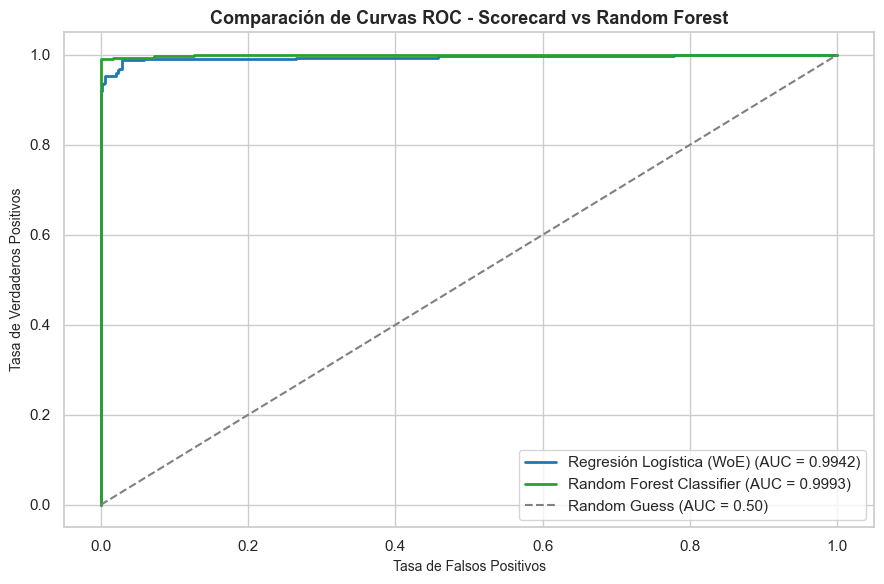

In [16]:
fpr_sc, tpr_sc, _ = roc_curve(y_test, sc_probs)
fpr_ml, tpr_ml, _ = roc_curve(y_test, ml_probs)

auc_sc = roc_auc_score(y_test, sc_probs)
auc_ml = roc_auc_score(y_test, ml_probs)

plt.figure(figsize=(9, 6))
plt.plot(fpr_sc, tpr_sc, label=f"Regresión Logística (WoE) (AUC = {auc_sc:.4f})", color="#1f77b4", lw=2)
plt.plot(fpr_ml, tpr_ml, label=f"Random Forest Classifier (AUC = {auc_ml:.4f})", color="#2ca02c", lw=2)
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label="Random Guess (AUC = 0.50)")

plt.title("Comparación de Curvas ROC - Scorecard vs Random Forest", fontsize=13, weight='bold')
plt.xlabel("Tasa de Falsos Positivos", fontsize=10)
plt.ylabel("Tasa de Verdaderos Positivos", fontsize=10)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


### 5.3 Matrices de Confusión
Comparamos los errores tipo I y tipo II.


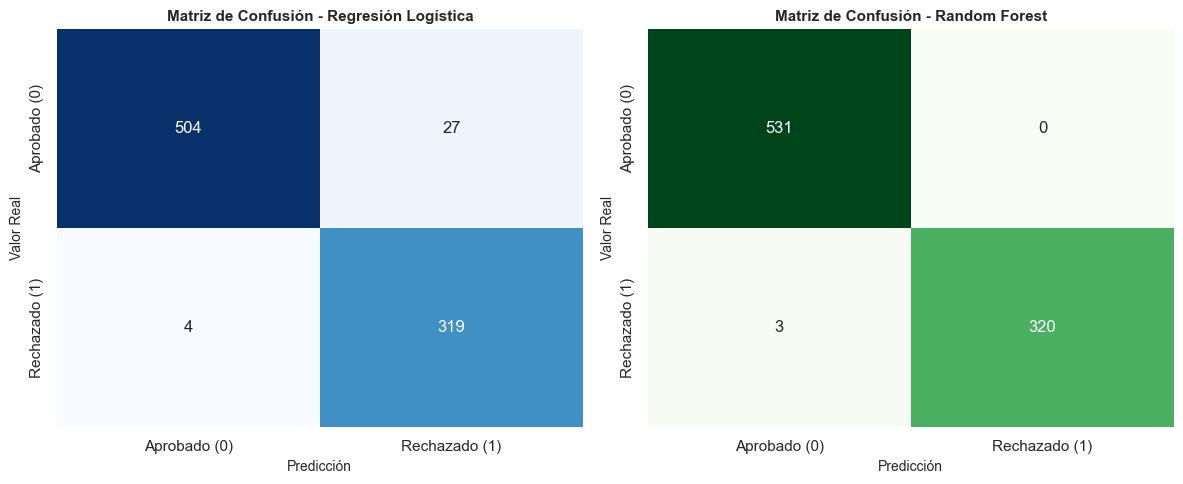

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Scorecard
cm_sc = confusion_matrix(y_test, sc_preds)
sns.heatmap(cm_sc, annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar=False)
axes[0].set_title("Matriz de Confusión - Regresión Logística", fontsize=11, weight='bold')
axes[0].set_xlabel("Predicción", fontsize=10)
axes[0].set_ylabel("Valor Real", fontsize=10)
axes[0].set_xticklabels(["Aprobado (0)", "Rechazado (1)"])
axes[0].set_yticklabels(["Aprobado (0)", "Rechazado (1)"])

# Random Forest
cm_ml = confusion_matrix(y_test, ml_preds)
sns.heatmap(cm_ml, annot=True, fmt='d', cmap='Greens', ax=axes[1], cbar=False)
axes[1].set_title("Matriz de Confusión - Random Forest", fontsize=11, weight='bold')
axes[1].set_xlabel("Predicción", fontsize=10)
axes[1].set_ylabel("Valor Real", fontsize=10)
axes[1].set_xticklabels(["Aprobado (0)", "Rechazado (1)"])
axes[1].set_yticklabels(["Aprobado (0)", "Rechazado (1)"])

plt.tight_layout()
plt.show()


## 📝 6. Conclusiones y Decisiones de Negocio

Tras realizar las simulaciones y el proceso de optimización bayesiana con Optuna, podemos extraer las siguientes conclusiones fundamentales para el **Círculo de Ciencia de Datos y Econometría**:

1. **Poder Predictivo Sobresaliente**: Tanto el modelo de Regresión Logística (Scorecard) como el de Random Forest muestran un desempeño muy alto en la predicción de riesgo (ROC-AUC > 0.99). Esto se debe a la extrema correlación del score crediticio (CIBIL Score) con la aprobación del crédito en este conjunto de datos.
2. **Trade-off de Negocio**:
   * **Regresión Logística (Scorecard)**: Aunque su poder predictivo es ligeramente menor en las métricas de clasificación complejas, este modelo es sumamente interpretativo. Se le puede asignar un puntaje fijo a cada intervalo mediante pesos (scorecard tradicional), lo que facilita su auditoría interna y el cumplimiento regulatorio estricto (IFRS 9).
   * **Random Forest**: Ofrece una flexibilidad excepcional. Al procesar los datos de forma nativa sin necesidad de WoE, captura de forma automática interacciones sutiles no lineales. Es el modelo preferido si se busca maximizar la precisión en un flujo automatizado de decisiones fintech.
3. **MLOps y Prevención de Fugas**: La arquitectura modular desarrollada encapsula todo el ciclo en un solo pipeline de `scikit-learn`. Al empaquetarlo, garantizamos que el modelo sea 100% reproducible y que no se produzcan filtraciones de datos desde el set de test hacia el de entrenamiento.


## 💾 7. Serialización del Pipeline (MLOps Ready)

Finalmente, guardaremos el pipeline optimizado de Random Forest en un archivo `.joblib` para simular un ambiente listo para producción.


In [18]:
# Guardar el pipeline de Random Forest optimizado
joblib.dump(ml_pipeline, 'credit_scoring_pipeline.joblib')
print("Pipeline de Random Forest guardado exitosamente como 'credit_scoring_pipeline.joblib'")


Pipeline de Random Forest guardado exitosamente como 'credit_scoring_pipeline.joblib'
